# Kaggle Complete Notebook: EagleVision Phase 1 Geometric Depth Improvement

This notebook runs the complete Phase 1 workflow for the EagleVision project on Kaggle.

It does all of the following in one place:

1. clone and install the repository
2. inspect the Kaggle dataset
3. normalize the dataset into the ScanNet-style layout expected by the repo
4. download a Depth Anything V2 checkpoint
5. generate Kaggle-local configs
6. run baseline evaluation
7. train the Phase 1 adaptation model
8. run adapted evaluation
9. compare baseline vs adapted metrics
10. export artifacts and a zip bundle

Confirmed dataset path for this notebook:

- `/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d`


## What Improvement We Are Testing

The proposed improvement is not a new learned renderer. The proposed improvement is a geometry-first training environment for improving a monocular depth estimator.

We compare:

- **baseline**: frozen Depth Anything V2
- **adapted**: Depth Anything V2 plus a lightweight residual adapter trained with round-trip geometric supervision

The key claim is that the adapted model should become more geometrically useful while preserving reasonable raw depth quality.


In [1]:
from pathlib import Path
import csv
import json
import os
import shutil
import subprocess
import sys
import zipfile
import torch
import yaml


In [2]:
KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_WORKING = Path('/kaggle/working')

REPO_URL = 'https://github.com/alooboii/EagleVision.git'
REPO_DIR = KAGGLE_WORKING / 'EagleVision'

# Confirmed dataset path for this Kaggle runtime
RAW_DATASET_DIR = Path('/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d')

print('KAGGLE_INPUT:', KAGGLE_INPUT)
print('KAGGLE_WORKING:', KAGGLE_WORKING)
print('RAW_DATASET_DIR:', RAW_DATASET_DIR)

if not RAW_DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset path not found: {RAW_DATASET_DIR}')


KAGGLE_INPUT: /kaggle/input
KAGGLE_WORKING: /kaggle/working
RAW_DATASET_DIR: /kaggle/input/datasets/klein2111/scannet-2d/scannet_2d


## Shell Helper

The helper below is deliberately non-fragile for Kaggle. It can capture stdout and stderr without hiding the actual failure reason when a command exits nonzero.


In [3]:
def run(cmd, cwd=None, capture=False, check=True):
    print('$', ' '.join(cmd))
    print(f'[status] cwd={cwd if cwd else Path.cwd()}')
    print('[status] command started')

    process = subprocess.Popen(
        cmd,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
    )

    output_lines = []
    if process.stdout is not None:
        for line in process.stdout:
            print(line, end='')
            output_lines.append(line)

    return_code = process.wait()
    print(f'[status] command finished with exit code {return_code}')

    completed = subprocess.CompletedProcess(
        args=cmd,
        returncode=return_code,
        stdout=''.join(output_lines),
        stderr='',
    )

    if check and completed.returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {completed.returncode}: {' '.join(cmd)}"
        )
    return completed


def is_git_repo(path: Path) -> bool:
    return (path / '.git').exists()


## Clone Or Refresh The Repository

This cell is careful about Kaggle workspaces where a leftover directory may exist without actually being a git checkout.


In [4]:
if REPO_DIR.exists() and not is_git_repo(REPO_DIR):
    print(f'Removing non-git directory at {REPO_DIR}')
    shutil.rmtree(REPO_DIR)

if is_git_repo(REPO_DIR):
    run(['git', 'fetch', '--all'], cwd=REPO_DIR)
    run(['git', 'pull', '--ff-only'], cwd=REPO_DIR)
else:
    run(['git', 'clone', REPO_URL, str(REPO_DIR)])

run(['python', '-m', 'pip', 'install', '-q', '-e', '.[dev]'], cwd=REPO_DIR)
print('repo ready:', REPO_DIR)


$ git clone https://github.com/alooboii/EagleVision.git /kaggle/working/EagleVision
[status] cwd=/kaggle/working
[status] command started
Cloning into '/kaggle/working/EagleVision'...
[status] command finished with exit code 0
$ python -m pip install -q -e .[dev]
[status] cwd=/kaggle/working/EagleVision
[status] command started
[status] command finished with exit code 0
repo ready: /kaggle/working/EagleVision


In [5]:
TRAIN_RUN_OUTPUT_DIR = REPO_DIR / 'outputs' / 'phase1_kaggle_complete'
CONFIG_DIR = REPO_DIR / 'outputs' / 'kaggle_configs'
TARGET_DATA_ROOT = REPO_DIR / 'data' / 'scannet'

for path in [TRAIN_RUN_OUTPUT_DIR, CONFIG_DIR, TARGET_DATA_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

# Make package imports robust in notebook kernels.
SRC_DIR = REPO_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
os.environ['PYTHONPATH'] = f"{SRC_DIR}:{os.environ.get('PYTHONPATH', '')}"

print('TRAIN_RUN_OUTPUT_DIR:', TRAIN_RUN_OUTPUT_DIR)
print('CONFIG_DIR:', CONFIG_DIR)
print('TARGET_DATA_ROOT:', TARGET_DATA_ROOT)
print('SRC_DIR:', SRC_DIR)


TRAIN_RUN_OUTPUT_DIR: /kaggle/working/EagleVision/outputs/phase1_kaggle_complete
CONFIG_DIR: /kaggle/working/EagleVision/outputs/kaggle_configs
TARGET_DATA_ROOT: /kaggle/working/EagleVision/data/scannet
SRC_DIR: /kaggle/working/EagleVision/src


## Inspect The Dataset

Before making any assumptions, inspect the first part of the directory tree. The screenshot you provided indicates scene folders with `color`, `depth`, `label`, and `pose`, which is exactly what we want.


In [6]:
preview = [str(path) for path in sorted(RAW_DATASET_DIR.iterdir())[:80]]
preview


['/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/intrinsics.txt',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0000_00',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0000_01',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0000_02',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0001_00',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0001_01',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0002_00',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0002_01',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0003_00',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0003_01',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0003_02',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0004_00',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene0005_00',
 '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d/scene

## Discover ScanNet-Style Scenes

We expect each scene to contain:

- `color/`
- `depth/`
- `pose/`

The extra `label/` directory is ignored.


In [7]:
def discover_scene_dirs(root: Path):
    scenes = []
    for candidate in sorted(root.iterdir()):
        if not candidate.is_dir():
            continue
        if (candidate / 'color').exists() and (candidate / 'depth').exists() and (candidate / 'pose').exists():
            scenes.append(candidate)
    return scenes

scene_dirs = discover_scene_dirs(RAW_DATASET_DIR)
print('num scenes found:', len(scene_dirs))
print('first scenes:', [p.name for p in scene_dirs[:10]])

if not scene_dirs:
    raise RuntimeError('No valid scene directories found.')


num scenes found: 1513
first scenes: ['scene0000_00', 'scene0000_01', 'scene0000_02', 'scene0001_00', 'scene0001_01', 'scene0002_00', 'scene0002_01', 'scene0003_00', 'scene0003_01', 'scene0003_02']


## Normalize Into `data/scannet`

The repository expects data to live under `data/scannet`. We symlink scenes where possible and copy only if necessary.


In [8]:
def materialize_scene(scene_dir: Path, target_root: Path):
    dst = target_root / scene_dir.name
    if dst.exists():
        return dst
    try:
        os.symlink(scene_dir, dst, target_is_directory=True)
    except OSError:
        shutil.copytree(scene_dir, dst)
    return dst

materialized = [materialize_scene(scene_dir, TARGET_DATA_ROOT) for scene_dir in scene_dirs]
scene_ids = sorted([p.name for p in TARGET_DATA_ROOT.iterdir() if p.is_dir()])

print('normalized scene count:', len(scene_ids))
print('example normalized scenes:', scene_ids[:10])


normalized scene count: 1513
example normalized scenes: ['scene0000_00', 'scene0000_01', 'scene0000_02', 'scene0001_00', 'scene0001_01', 'scene0002_00', 'scene0002_01', 'scene0003_00', 'scene0003_01', 'scene0003_02']


In [9]:
first_scene = TARGET_DATA_ROOT / scene_ids[0]
print('scene:', first_scene.name)
print('color sample:', [p.name for p in sorted((first_scene / 'color').glob('*'))[:5]])
print('depth sample:', [p.name for p in sorted((first_scene / 'depth').glob('*'))[:5]])
print('pose sample:', [p.name for p in sorted((first_scene / 'pose').glob('*'))[:5]])


scene: scene0000_00
color sample: ['0.jpg', '100.jpg', '1000.jpg', '1020.jpg', '1040.jpg']
depth sample: ['0.png', '100.png', '1000.png', '1020.png', '1040.png']
pose sample: ['0.txt', '100.txt', '1000.txt', '1020.txt', '1040.txt']


## Train / Validation Split

We create a simple scene-based split for the Kaggle run.


In [10]:
all_scene_ids = list(scene_ids)
print('total normalized scenes available:', len(all_scene_ids))
print('scene sample:', all_scene_ids[:10])


total normalized scenes available: 1513
scene sample: ['scene0000_00', 'scene0000_01', 'scene0000_02', 'scene0001_00', 'scene0001_01', 'scene0002_00', 'scene0002_01', 'scene0003_00', 'scene0003_01', 'scene0003_02']


## Download The Baseline Checkpoint

For Kaggle, we use the `vits` metric-depth model with the `hypersim` indoor profile.


In [11]:
print('[status] downloading Depth Anything V2 checkpoints for vits (metric + relative)')
run(
    [
        'python', '-m', 'baseline.depth_anything_v2', 'download',
        '--mode', 'all',
        '--profile', 'hypersim',
        '--encoder', 'vits',
    ],
    cwd=REPO_DIR,
)


[status] downloading Depth Anything V2 checkpoints for vits (metric + relative)
$ python -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
[status] cwd=/kaggle/working/EagleVision
[status] command started
relative:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_vits.pth (downloaded)
metric:hypersim:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth (downloaded)
[status] command finished with exit code 0


CompletedProcess(args=['python', '-m', 'baseline.depth_anything_v2', 'download', '--mode', 'all', '--profile', 'hypersim', '--encoder', 'vits'], returncode=0, stdout='relative:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_vits.pth (downloaded)\nmetric:hypersim:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth (downloaded)\n', stderr='')

In [12]:
checkpoint_dir = REPO_DIR / 'baseline' / 'depth_anything_v2' / 'checkpoints'
checkpoint_files = list(checkpoint_dir.glob('*.pth'))
print('checkpoint dir:', checkpoint_dir)
print('checkpoint files:', checkpoint_files)

if not checkpoint_files:
    raise RuntimeError('No checkpoint file found after download.')


checkpoint dir: /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints
checkpoint files: [PosixPath('/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_vits.pth'), PosixPath('/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth')]


## Build Kaggle-Local Train And Eval Configs

Edit only the next cell (`Single Control Cell`). Both baseline and adapted evaluation will use the same fair settings from that cell.


In [13]:
# ===================== Single Control Cell (Edit Only Here) =====================
# Baseline vs adapted fairness rule in this notebook:
# 1) Same eval config file
# 2) Same scenes and pairing thresholds
# 3) Same image size and model settings
# 4) Same --max-batches cap
# 5) Only difference: baseline uses --baseline-only, adapted loads checkpoint


EXPERIMENT_TAG = 'phase1_kaggle_heavy_v1'
SEED = 7

SCENE_LIMIT = None                 # use all discovered scenes None
TRAIN_SCENE_FRACTION = 0.90
IMAGE_SIZE = [192, 288]            # if OOM, drop to [176, 256]

# Choose depth mode: 'metric' or 'relative'
# - metric: recommended for Phase 1 training with GT depth anchoring.
# - relative: works, but use geometry/RGB losses only (depth metric losses disabled below).
DEPTH_MODE = 'metric'
DEPTH_ENCODER = 'vits'
METRIC_PROFILE = 'hypersim'  # used only when DEPTH_MODE == 'metric'

# Pair sampling controls
PAIRING = {
    'min_translation_m': 0.02,
    'max_translation_m': 0.30,
    'min_rotation_deg': 0.8,
    'max_rotation_deg': 8.0,
    'max_index_gap': 10,
    'frame_stride': 2,
    'max_frames_per_scene': 180,
    'max_pairs_per_scene': 120,
}

device_name = "cuda" if torch.cuda.is_available() else "cpu"


# Resolve pretrained checkpoint according to selected mode.
if DEPTH_MODE == 'metric':
    ckpt_name = f'depth_anything_v2_metric_{METRIC_PROFILE}_{DEPTH_ENCODER}.pth'
else:
    ckpt_name = f'depth_anything_v2_{DEPTH_ENCODER}.pth'
DEFAULT_DEPTH_CKPT = REPO_DIR / 'baseline' / 'depth_anything_v2' / 'checkpoints' / ckpt_name
if not DEFAULT_DEPTH_CKPT.exists():
    raise FileNotFoundError(
        f'Missing pretrained DA-V2 checkpoint: {DEFAULT_DEPTH_CKPT}. Run the download cell first.'
    )

# Depth model controls (shared by train and eval)
DEPTH_MODEL_SETTINGS = {
    'mode': DEPTH_MODE,
    'encoder': DEPTH_ENCODER,
    'profile': METRIC_PROFILE,
    'checkpoint_path': str(DEFAULT_DEPTH_CKPT),
    'freeze_backbone': True,
    'adapter_hidden_channels': 32,   # up from 24
}



NO_EVAL_DURING_TRAIN = True

# 5-6h target on your current speed
TRAIN_SETTINGS = {
    'batch_size': 1,
    'epochs': 70,                  # ~5–6h on your current speed  
    'max_steps_per_epoch': None,   # IMPORTANT: remove 500-step cap  N
    'lr': 2e-5,                    # safer for long run
    'weight_decay': 1e-4,
    'log_interval': 100,
    'vis_interval': 10_000_000,    # disable panel rendering overhead
    'checkpoint_interval': 10_000_000,  # only epoch-end checkpoints
}

# keep fair eval cap for quick compare
EVAL_SETTINGS = {
    'batch_size': 1,
    'max_batches': 780,   # full val set 780
}



# In relative mode, disable metric-depth losses by default (scale ambiguity).
if DEPTH_MODE == 'relative':
    LOSS_WEIGHTS = {
        'target_rgb': 1.0,
        'cycle_rgb': 1.0,
        'cycle_depth': 0.0,
        'target_depth': 0.0,
    }
else:
    LOSS_WEIGHTS = {
        'target_rgb': 1.0,
        'cycle_rgb': 1.0,
        'cycle_depth': 0.35,
        'target_depth': 0.35,
    }

# ScanNet default intrinsics used by this notebook's resized samples
intrinsics = [
    [577.8706, 0.0, 159.5],
    [0.0, 577.8706, 119.5],
    [0.0, 0.0, 1.0],
]

scene_pool = list(all_scene_ids if 'all_scene_ids' in globals() else scene_ids)
if len(scene_pool) < 2:
    raise RuntimeError('Need at least 2 scenes for train/val split.')

if SCENE_LIMIT is not None:
    scene_ids = scene_pool[:SCENE_LIMIT]
else:
    scene_ids = scene_pool

split_index = max(1, int(TRAIN_SCENE_FRACTION * len(scene_ids)))
train_scenes = scene_ids[:split_index]
val_scenes = scene_ids[split_index:] if split_index < len(scene_ids) else scene_ids[:1]

TRAIN_RUN_OUTPUT_DIR = REPO_DIR / 'outputs' / EXPERIMENT_TAG
TRAIN_RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_config = {
    'seed': SEED,
    'device': device_name,
    'output_dir': str(TRAIN_RUN_OUTPUT_DIR),
    'data': {
        'root': str(TARGET_DATA_ROOT),
        'image_size': IMAGE_SIZE,
        'intrinsics': intrinsics,
        'pairing': dict(PAIRING),
        'splits': {
            'train': {'scenes': train_scenes},
        },
    },
    'model': {
        'depth': dict(DEPTH_MODEL_SETTINGS),
    },
    'train': dict(TRAIN_SETTINGS),
    'eval': dict(EVAL_SETTINGS),
    'losses': {
        'weights': dict(LOSS_WEIGHTS),
    },
}

eval_config = {
    'seed': SEED,
    'device': device_name,
    'data': {
        'root': str(TARGET_DATA_ROOT),
        'image_size': IMAGE_SIZE,
        'intrinsics': intrinsics,
        'pairing': dict(PAIRING),
        'splits': {
            'val': {'scenes': val_scenes},
        },
    },
    'model': {
        'depth': dict(DEPTH_MODEL_SETTINGS),
    },
    'eval': dict(EVAL_SETTINGS),
    'losses': {
        'weights': dict(LOSS_WEIGHTS),
    },
}

train_config_path = CONFIG_DIR / f'train_{EXPERIMENT_TAG}.yaml'
eval_config_path = CONFIG_DIR / f'eval_{EXPERIMENT_TAG}.yaml'
with train_config_path.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(train_config, handle, sort_keys=False)
with eval_config_path.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(eval_config, handle, sort_keys=False)

FAIR_EVAL_ARGS = [
    '--config', str(eval_config_path),
    '--max-batches', str(EVAL_SETTINGS['max_batches']),
]

print('device:', device_name)
print('train config:', train_config_path)
print('eval config:', eval_config_path)
print('train scenes:', len(train_scenes), 'val scenes:', len(val_scenes))
print('fair eval args:', FAIR_EVAL_ARGS)
print('depth mode:', DEPTH_MODE)
print('shared depth settings:', DEPTH_MODEL_SETTINGS)
print('pretrained depth checkpoint:', DEFAULT_DEPTH_CKPT)
print('loss weights:', LOSS_WEIGHTS)


device: cuda
train config: /kaggle/working/EagleVision/outputs/kaggle_configs/train_phase1_kaggle_heavy_v1.yaml
eval config: /kaggle/working/EagleVision/outputs/kaggle_configs/eval_phase1_kaggle_heavy_v1.yaml
train scenes: 1361 val scenes: 152
fair eval args: ['--config', '/kaggle/working/EagleVision/outputs/kaggle_configs/eval_phase1_kaggle_heavy_v1.yaml', '--max-batches', '780']
depth mode: metric
shared depth settings: {'mode': 'metric', 'encoder': 'vits', 'profile': 'hypersim', 'checkpoint_path': '/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth', 'freeze_backbone': True, 'adapter_hidden_channels': 32}
pretrained depth checkpoint: /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth
loss weights: {'target_rgb': 1.0, 'cycle_rgb': 1.0, 'cycle_depth': 0.35, 'target_depth': 0.35}


## Metric Parser

The evaluation CLI prints metrics to stdout. This helper turns that text into a dictionary for comparison and export.


In [14]:
def parse_metric_output(stdout_text: str):
    metrics = {}
    for line in stdout_text.splitlines():
        if ': ' not in line:
            continue
        key, value = line.split(': ', 1)
        try:
            metrics[key.strip()] = float(value.strip())
        except ValueError:
            continue
    return metrics


## Baseline Evaluation

This measures the frozen baseline before any adaptation.


In [15]:
print('[status] starting baseline evaluation (fair settings)')
baseline_eval = run(
    ['python', '-m', 'eaglevision.cli.eval', *FAIR_EVAL_ARGS, '--baseline-only'],
    cwd=REPO_DIR,
    capture=True,
    check=False,
)

print('baseline return code:', baseline_eval.returncode)
if baseline_eval.returncode != 0:
    raise RuntimeError('Baseline evaluation failed. Read streamed output above.')


[status] starting baseline evaluation (fair settings)
$ python -m eaglevision.cli.eval --config /kaggle/working/EagleVision/outputs/kaggle_configs/eval_phase1_kaggle_heavy_v1.yaml --max-batches 780 --baseline-only
[status] cwd=/kaggle/working/EagleVision
[status] command started
Loading evaluation config from /kaggle/working/EagleVision/outputs/kaggle_configs/eval_phase1_kaggle_heavy_v1.yaml
Evaluating on device=cuda
Built evaluation dataset with 549 pairs from 152 scenes
Running baseline-only evaluation with zeroed adapter
Using max_batches=780
Starting metric computation
Starting evaluation on device=cuda with 549 batches

eval: 100%|██████████| 549/549 [00:46<00:00, 11.68it/s, cycle_rgb_l1=0.1765, reproj=0.2733, target_rgb_l1=0.1600]
[eval] batch 1/549 target_rgb_l1=0.3424 cycle_rgb_l1=0.0972 psnr=12.13 ssim=0.0483 reprojection_depth=0.6698
[eval] batch 10/549 target_rgb_l1=0.3208 cycle_rgb_l1=0.0566 psnr=14.47 ssim=0.3951 reprojection_depth=0.4212
[eval] batch 20/549 target_rgb_l1=

In [16]:
baseline_metrics = parse_metric_output(baseline_eval.stdout)
baseline_metrics_path = TRAIN_RUN_OUTPUT_DIR / 'baseline_metrics.yaml'

with baseline_metrics_path.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(baseline_metrics, handle, sort_keys=False)

baseline_metrics


{'target_rgb_l1': 0.210844,
 'cycle_rgb_l1': 0.121512,
 'psnr': 15.532736,
 'ssim': 0.119414,
 'reprojection_depth': 1.613487,
 'depth_l1': 2.717626,
 'rmse': 2.877087,
 'abs_rel': 0.409095,
 'loss_total': 1.848245,
 'loss_target_rgb': 0.210844,
 'loss_cycle_rgb': 0.121512,
 'loss_cycle_depth': 1.613487,
 'loss_target_depth': 2.717626}

## Train The Phase 1 Adaptation Model

This is the proposed improvement step: geometry-first round-trip supervision over a mostly frozen depth backbone with a lightweight adaptation head.


In [17]:
print('[status] starting Phase 1 training run')
train_run = run(
    ['python', '-m', 'eaglevision.cli.train', '--config', str(train_config_path)],
    cwd=REPO_DIR,
    capture=True,
    check=False,
)

print('train return code:', train_run.returncode)
if train_run.returncode != 0:
    raise RuntimeError('Training failed. Read streamed output above.')


[status] starting Phase 1 training run
$ python -m eaglevision.cli.train --config /kaggle/working/EagleVision/outputs/kaggle_configs/train_phase1_kaggle_heavy_v1.yaml
[status] cwd=/kaggle/working/EagleVision
[status] command started
Loading training config from /kaggle/working/EagleVision/outputs/kaggle_configs/train_phase1_kaggle_heavy_v1.yaml
Training on device=cuda
Built train dataset with 3454 pairs
Writing outputs to /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1

epoch 1/70: 100%|██████████| 3454/3454 [04:04<00:00, 14.12it/s]

epoch 2/70: 100%|██████████| 3454/3454 [02:33<00:00, 22.56it/s]

epoch 3/70: 100%|██████████| 3454/3454 [02:36<00:00, 22.11it/s]

epoch 4/70: 100%|██████████| 3454/3454 [02:37<00:00, 21.92it/s]

epoch 5/70: 100%|██████████| 3454/3454 [02:35<00:00, 22.22it/s]

epoch 6/70: 100%|██████████| 3454/3454 [02:33<00:00, 22.52it/s]

epoch 7/70: 100%|██████████| 3454/3454 [02:33<00:00, 22.57it/s]

epoch 8/70: 100%|██████████| 3454/3454 [02:32<00:00, 22.61i

In [18]:
checkpoint_dir = TRAIN_RUN_OUTPUT_DIR / 'checkpoints'
checkpoints = sorted(checkpoint_dir.glob('*.pt'))
print('checkpoints:', checkpoints)

if not checkpoints:
    raise RuntimeError(f'No checkpoints found in {checkpoint_dir}')

latest_checkpoint = checkpoints[-1]
latest_checkpoint


checkpoints: [PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_001_final_step_0003454.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_002_final_step_0006908.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_003_final_step_0010362.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_004_final_step_0013816.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_005_final_step_0017270.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_006_final_step_0020724.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_007_final_step_0024178.pt'), PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_008_final_step_0027632.pt'), PosixPath('/kaggle/working/EagleVision/outputs/pha

PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_070_final_step_0241780.pt')

## Adapted Evaluation

This measures the trained adapted model using the latest checkpoint from the training run.


In [19]:
print('[status] starting adapted evaluation (same fair settings)')
adapted_eval = run(
    ['python', '-m', 'eaglevision.cli.eval', *FAIR_EVAL_ARGS, '--checkpoint', str(latest_checkpoint)],
    cwd=REPO_DIR,
    capture=True,
    check=False,
)

print('adapted return code:', adapted_eval.returncode)
if adapted_eval.returncode != 0:
    raise RuntimeError('Adapted evaluation failed. Read streamed output above.')


[status] starting adapted evaluation (same fair settings)
$ python -m eaglevision.cli.eval --config /kaggle/working/EagleVision/outputs/kaggle_configs/eval_phase1_kaggle_heavy_v1.yaml --max-batches 780 --checkpoint /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_070_final_step_0241780.pt
[status] cwd=/kaggle/working/EagleVision
[status] command started
Loading evaluation config from /kaggle/working/EagleVision/outputs/kaggle_configs/eval_phase1_kaggle_heavy_v1.yaml
Evaluating on device=cuda
Built evaluation dataset with 549 pairs from 152 scenes
Loading checkpoint from /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_070_final_step_0241780.pt
Using max_batches=780
Starting metric computation
Starting evaluation on device=cuda with 549 batches

eval: 100%|██████████| 549/549 [00:31<00:00, 17.33it/s, cycle_rgb_l1=0.1579, reproj=0.2969, target_rgb_l1=0.1600]
[eval] batch 1/549 target_rgb_l1=0.3424 cycle_rgb_l1=0.0891 psnr=12.58 ssim

In [20]:
adapted_metrics = parse_metric_output(adapted_eval.stdout)
adapted_metrics_path = TRAIN_RUN_OUTPUT_DIR / 'adapted_metrics.yaml'

with adapted_metrics_path.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(adapted_metrics, handle, sort_keys=False)

adapted_metrics


{'target_rgb_l1': 0.210844,
 'cycle_rgb_l1': 0.118528,
 'psnr': 14.25576,
 'ssim': 0.124642,
 'reprojection_depth': 1.505939,
 'depth_l1': 2.590427,
 'rmse': 2.751393,
 'abs_rel': 0.331596,
 'loss_total': 1.7631,
 'loss_target_rgb': 0.210844,
 'loss_cycle_rgb': 0.118528,
 'loss_cycle_depth': 1.505939,
 'loss_target_depth': 2.590427}

## Compare Baseline And Adapted Metrics

This is the central proof step for the proposed improvement.

Interpretation:

- lower is better for `target_rgb_l1`, `cycle_rgb_l1`, `reprojection_depth`, `depth_l1`, `rmse`, `abs_rel`
- higher is better for `psnr` and `ssim`


In [21]:
metric_names = sorted(set(baseline_metrics) | set(adapted_metrics))
comparison_rows = []

for metric_name in metric_names:
    baseline_value = baseline_metrics.get(metric_name)
    adapted_value = adapted_metrics.get(metric_name)
    delta = None
    if baseline_value is not None and adapted_value is not None:
        delta = adapted_value - baseline_value
    comparison_rows.append(
        {
            'metric': metric_name,
            'baseline': baseline_value,
            'adapted': adapted_value,
            'delta': delta,
        }
    )

comparison_rows


[{'metric': 'abs_rel',
  'baseline': 0.409095,
  'adapted': 0.331596,
  'delta': -0.07749899999999998},
 {'metric': 'cycle_rgb_l1',
  'baseline': 0.121512,
  'adapted': 0.118528,
  'delta': -0.0029840000000000005},
 {'metric': 'depth_l1',
  'baseline': 2.717626,
  'adapted': 2.590427,
  'delta': -0.12719900000000006},
 {'metric': 'loss_cycle_depth',
  'baseline': 1.613487,
  'adapted': 1.505939,
  'delta': -0.10754799999999998},
 {'metric': 'loss_cycle_rgb',
  'baseline': 0.121512,
  'adapted': 0.118528,
  'delta': -0.0029840000000000005},
 {'metric': 'loss_target_depth',
  'baseline': 2.717626,
  'adapted': 2.590427,
  'delta': -0.12719900000000006},
 {'metric': 'loss_target_rgb',
  'baseline': 0.210844,
  'adapted': 0.210844,
  'delta': 0.0},
 {'metric': 'loss_total',
  'baseline': 1.848245,
  'adapted': 1.7631,
  'delta': -0.08514500000000003},
 {'metric': 'psnr',
  'baseline': 15.532736,
  'adapted': 14.25576,
  'delta': -1.2769759999999994},
 {'metric': 'reprojection_depth',
  'ba

In [22]:
comparison_json_path = TRAIN_RUN_OUTPUT_DIR / 'comparison_metrics.json'
comparison_csv_path = TRAIN_RUN_OUTPUT_DIR / 'comparison_metrics.csv'

with comparison_json_path.open('w', encoding='utf-8') as handle:
    json.dump(comparison_rows, handle, indent=2)

with comparison_csv_path.open('w', encoding='utf-8', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=['metric', 'baseline', 'adapted', 'delta'])
    writer.writeheader()
    writer.writerows(comparison_rows)

print(comparison_json_path)
print(comparison_csv_path)


/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/comparison_metrics.json
/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/comparison_metrics.csv


## Result Analysis And Consolidation Plots

These cells summarize whether adapted metrics improved in the expected direction and visualize effect size.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(comparison_rows)
df = df.sort_values('metric').reset_index(drop=True)

lower_better = {
    'target_rgb_l1', 'cycle_rgb_l1', 'reprojection_depth',
    'depth_l1', 'rmse', 'abs_rel',
    'loss_total', 'loss_target_rgb', 'loss_cycle_rgb', 'loss_cycle_depth', 'loss_target_depth',
}
higher_better = {'psnr', 'ssim'}

def direction(metric: str) -> str:
    if metric in lower_better:
        return 'lower_better'
    if metric in higher_better:
        return 'higher_better'
    return 'unknown'

df['direction'] = df['metric'].map(direction)
df['improved'] = np.where(
    df['direction'].eq('lower_better'), df['delta'] < 0,
    np.where(df['direction'].eq('higher_better'), df['delta'] > 0, np.nan)
)
df['rel_change_pct'] = 100.0 * (df['adapted'] - df['baseline']) / (df['baseline'].replace(0, np.nan))

tracked = df[df['direction'] != 'unknown'].copy()
num_improved = int(tracked['improved'].fillna(False).sum())
num_total = int(len(tracked))
print(f'Improved metrics (direction-aware): {num_improved}/{num_total}')
display(df[['metric','baseline','adapted','delta','rel_change_pct','direction','improved']])


Improved metrics (direction-aware): 10/13


,metric,baseline,adapted,delta,rel_change_pct,direction,improved
0,abs_rel,0.409095,0.331596,-0.077499,-18.944011,lower_better,1.0
1,cycle_rgb_l1,0.121512,0.118528,-0.002984,-2.455725,lower_better,1.0
2,depth_l1,2.717626,2.590427,-0.127199,-4.680519,lower_better,1.0
3,loss_cycle_depth,1.613487,1.505939,-0.107548,-6.665563,lower_better,1.0
4,loss_cycle_rgb,0.121512,0.118528,-0.002984,-2.455725,lower_better,1.0
5,loss_target_depth,2.717626,2.590427,-0.127199,-4.680519,lower_better,1.0
6,loss_target_rgb,0.210844,0.210844,0.000000,0.000000,lower_better,0.0
7,loss_total,1.848245,1.763100,-0.085145,-4.606803,lower_better,1.0
8,psnr,15.532736,14.255760,-1.276976,-8.221192,higher_better,0.0
9,reprojection_depth,1.613487,1.505939,-0.107548,-6.665563,lower_better,1.0


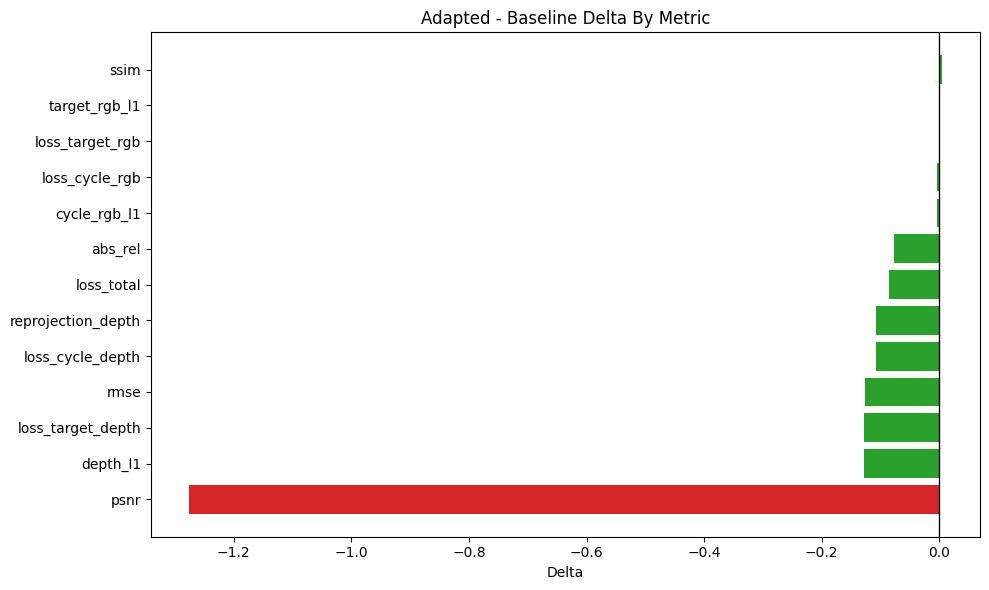

In [24]:
plot_df = df[df['delta'].notna()].copy()
plot_df = plot_df.sort_values('delta')

colors = []
for _, row in plot_df.iterrows():
    if row['direction'] == 'lower_better':
        colors.append('#2ca02c' if row['delta'] < 0 else '#d62728')
    elif row['direction'] == 'higher_better':
        colors.append('#2ca02c' if row['delta'] > 0 else '#d62728')
    else:
        colors.append('#7f7f7f')

plt.figure(figsize=(10, max(6, 0.4 * len(plot_df))))
plt.barh(plot_df['metric'], plot_df['delta'], color=colors)
plt.axvline(0.0, color='black', linewidth=1)
plt.title('Adapted - Baseline Delta By Metric')
plt.xlabel('Delta')
plt.tight_layout()
plt.show()


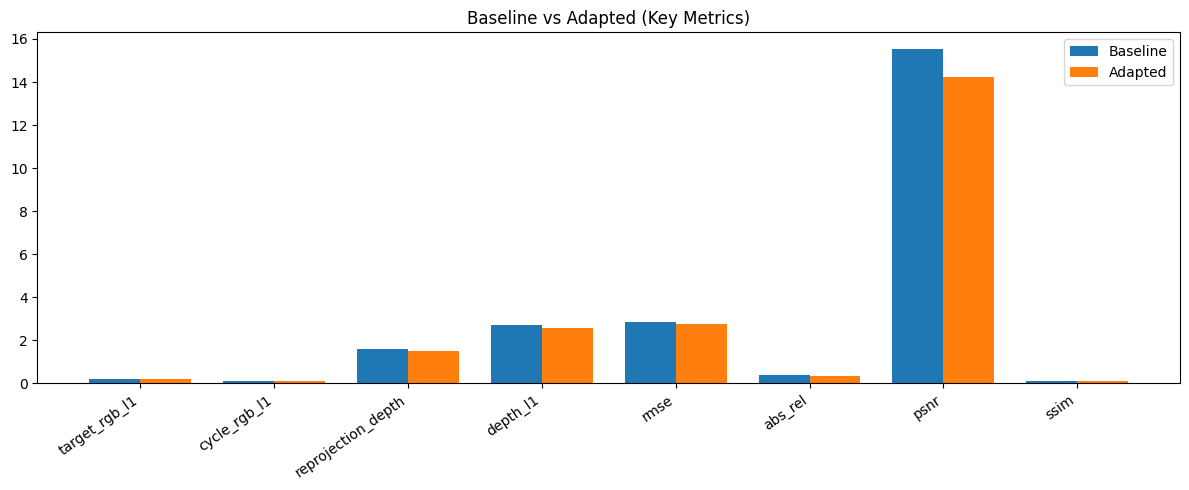

Direction reference: lower is better for L1/RMSE/AbsRel/reprojection; higher is better for PSNR/SSIM.


In [25]:
focus_metrics = [
    'target_rgb_l1', 'cycle_rgb_l1', 'reprojection_depth',
    'depth_l1', 'rmse', 'abs_rel', 'psnr', 'ssim',
]
focus = df[df['metric'].isin(focus_metrics)].copy()
focus = focus.set_index('metric').loc[[m for m in focus_metrics if m in set(focus['metric'])]].reset_index()

x = np.arange(len(focus))
w = 0.38
plt.figure(figsize=(12, 5))
plt.bar(x - w/2, focus['baseline'], width=w, label='Baseline', color='#1f77b4')
plt.bar(x + w/2, focus['adapted'], width=w, label='Adapted', color='#ff7f0e')
plt.xticks(x, focus['metric'], rotation=35, ha='right')
plt.title('Baseline vs Adapted (Key Metrics)')
plt.legend()
plt.tight_layout()
plt.show()

print('Direction reference: lower is better for L1/RMSE/AbsRel/reprojection; higher is better for PSNR/SSIM.')


found comparison files: 1
- /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/comparison_metrics.json


,metric,count,mean,std
0,abs_rel,1,-0.077499,NaN
1,cycle_rgb_l1,1,-0.002984,NaN
2,depth_l1,1,-0.127199,NaN
3,psnr,1,-1.276976,NaN
4,reprojection_depth,1,-0.107548,NaN
5,rmse,1,-0.125694,NaN
6,ssim,1,0.005228,NaN
7,target_rgb_l1,1,0.000000,NaN


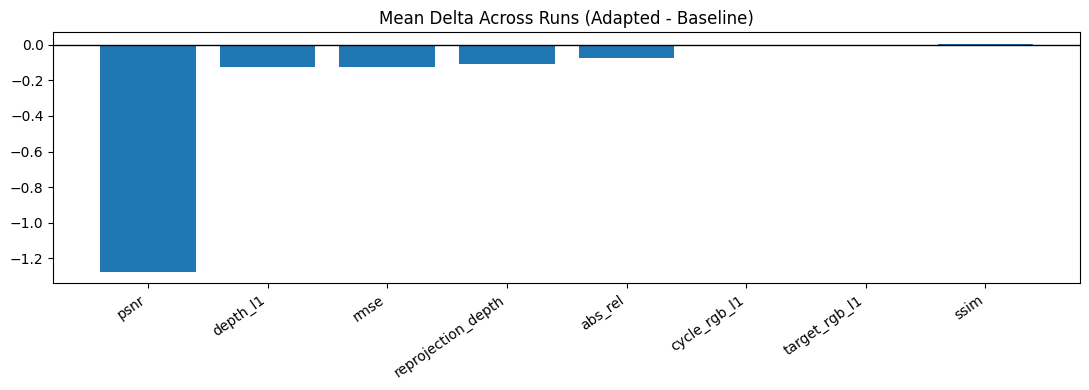

In [26]:
# Optional: aggregate multiple run comparisons if present under outputs/**/comparison_metrics.json
all_cmp_files = sorted((REPO_DIR / 'outputs').rglob('comparison_metrics.json'))
print('found comparison files:', len(all_cmp_files))
for pth in all_cmp_files[:10]:
    print('-', pth)

rows = []
for cmp_path in all_cmp_files:
    run_name = cmp_path.parent.name
    with cmp_path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    for item in data:
        rows.append({'run': run_name, **item})

if rows:
    runs_df = pd.DataFrame(rows)
    tracked = runs_df[runs_df['metric'].isin(focus_metrics)].copy()
    if not tracked.empty:
        summary = tracked.groupby('metric')['delta'].agg(['count','mean','std']).reset_index()
        display(summary.sort_values('metric'))

        plt.figure(figsize=(11, 4))
        ordered = summary.sort_values('mean')
        plt.bar(ordered['metric'], ordered['mean'], color='#1f77b4')
        plt.axhline(0.0, color='black', linewidth=1)
        plt.xticks(rotation=35, ha='right')
        plt.title('Mean Delta Across Runs (Adapted - Baseline)')
        plt.tight_layout()
        plt.show()
    else:
        print('No focus metrics found in aggregated run files.')
else:
    print('No comparison files found yet. Re-run this cell after multiple experiments.')


## Baseline vs Adapted Depth Visualization (Input + Novel View)

This section shows pure depth estimation visuals only (no difference heatmaps):
- source input RGB: baseline depth vs adapted depth
- forward-warped novel RGB: baseline depth vs adapted depth

Note: forward warp is sparse geometry, so black regions in novel RGB are expected holes (no inpainting in Phase 1).
In relative mode, absolute numeric depth is arbitrary; compare spatial structure rather than absolute scale.



In [27]:
import os, sys
from pathlib import Path
import importlib

REPO_DIR = Path("/kaggle/working/EagleVision")
SRC_DIR = REPO_DIR / "src"

# Make both eaglevision (src) and baseline (repo root) importable
for p in (str(REPO_DIR), str(SRC_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ["PYTHONPATH"] = f"{REPO_DIR}:{SRC_DIR}:{os.environ.get('PYTHONPATH', '')}"
importlib.invalidate_caches()

print("REPO in path:", str(REPO_DIR) in sys.path)
print("SRC in path :", str(SRC_DIR) in sys.path)


REPO in path: True
SRC in path : True


In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from eaglevision.data.pair_sampler import PairSamplingConfig
from eaglevision.data.scannet_dataset import ScanNetPairDataset
from eaglevision.engine.checkpointing import load_checkpoint
from eaglevision.models.depth.depth_anything_wrapper import DepthAnythingWithAdapter
from eaglevision.models.nvs.geometric_warp import GeometricWarper
from eaglevision.models.rt_depthnvs import RoundTripDepthNVS

viz_device = torch.device(device_name if torch.cuda.is_available() else 'cpu')

if 'latest_checkpoint' not in globals() or latest_checkpoint is None:
    checkpoint_candidates = sorted((TRAIN_RUN_OUTPUT_DIR / 'checkpoints').glob('*.pt'))
    if not checkpoint_candidates:
        raise RuntimeError('No training checkpoint available for adapted-depth visualization.')
    latest_checkpoint = checkpoint_candidates[-1]

if DEPTH_MODEL_SETTINGS.get('checkpoint_path') is None:
    raise RuntimeError('DEPTH_MODEL_SETTINGS.checkpoint_path is None. Baseline would not be pretrained.')

pair_cfg = PairSamplingConfig(**PAIRING)
base_intrinsics = np.array(intrinsics, dtype=np.float32)

viz_scenes = list(val_scenes)
if not viz_scenes:
    viz_scenes = list(train_scenes[:1])

viz_dataset = ScanNetPairDataset(
    root=TARGET_DATA_ROOT,
    scenes=viz_scenes,
    image_size=tuple(IMAGE_SIZE),
    intrinsics=base_intrinsics,
    pair_config=pair_cfg,
)
if len(viz_dataset) == 0:
    viz_dataset = ScanNetPairDataset(
        root=TARGET_DATA_ROOT,
        scenes=list(train_scenes),
        image_size=tuple(IMAGE_SIZE),
        intrinsics=base_intrinsics,
        pair_config=pair_cfg,
    )
if len(viz_dataset) == 0:
    raise RuntimeError('No valid pairs available for visualization. Relax pairing controls in the single control cell.')

sample = viz_dataset[0]

source_rgb = sample['source_rgb'].unsqueeze(0).to(viz_device)
source_depth = sample['source_depth'].unsqueeze(0).to(viz_device)
source_k = sample['source_intrinsics'].unsqueeze(0).to(viz_device)
target_k = sample['target_intrinsics'].unsqueeze(0).to(viz_device)
source_pose = sample['source_pose'].unsqueeze(0).to(viz_device)
target_pose = sample['target_pose'].unsqueeze(0).to(viz_device)

t_s2t = target_pose @ torch.inverse(source_pose)
warper = GeometricWarper().to(viz_device).eval()

base_depth_model = DepthAnythingWithAdapter(**DEPTH_MODEL_SETTINGS).to(viz_device).eval()
for parameter in base_depth_model.adapter.parameters():
    parameter.data.zero_()
    parameter.requires_grad = False

adapted_depth_model = DepthAnythingWithAdapter(**DEPTH_MODEL_SETTINGS).to(viz_device)
adapted_roundtrip = RoundTripDepthNVS(adapted_depth_model).to(viz_device).eval()
load_checkpoint(latest_checkpoint, adapted_roundtrip)

with torch.no_grad():
    forward = warper(source_rgb, source_depth, source_k, target_k, t_s2t)
    novel_rgb = forward['warped_rgb']

    baseline_source_pack = base_depth_model(source_rgb)
    baseline_novel_pack = base_depth_model(novel_rgb)

    adapted_source_pack = adapted_roundtrip.depth_model(source_rgb)
    adapted_novel_pack = adapted_roundtrip.depth_model(novel_rgb)

    source_depth_baseline = baseline_source_pack['adapted_depth'][0].detach().cpu().numpy()
    source_depth_adapted = adapted_source_pack['adapted_depth'][0].detach().cpu().numpy()

    novel_depth_baseline = baseline_novel_pack['adapted_depth'][0].detach().cpu().numpy()
    novel_depth_adapted = adapted_novel_pack['adapted_depth'][0].detach().cpu().numpy()

source_rgb_np = source_rgb[0].detach().cpu().permute(1, 2, 0).numpy().clip(0.0, 1.0)
novel_rgb_np = novel_rgb[0].detach().cpu().permute(1, 2, 0).numpy().clip(0.0, 1.0)

joint = np.concatenate(
    [
        source_depth_baseline.reshape(-1),
        source_depth_adapted.reshape(-1),
        novel_depth_baseline.reshape(-1),
        novel_depth_adapted.reshape(-1),
    ]
)
finite = np.isfinite(joint)
vmin, vmax = (np.percentile(joint[finite], 2), np.percentile(joint[finite], 98)) if finite.any() else (0.0, 1.0)

baseline_zero_adapter_source_mae = float(
    (baseline_source_pack['adapted_depth'] - baseline_source_pack['base_depth']).abs().mean().item()
)
baseline_zero_adapter_novel_mae = float(
    (baseline_novel_pack['adapted_depth'] - baseline_novel_pack['base_depth']).abs().mean().item()
)
adapted_residual_source_mae = float(
    (adapted_source_pack['adapted_depth'] - adapted_source_pack['base_depth']).abs().mean().item()
)
adapted_residual_novel_mae = float(
    (adapted_novel_pack['adapted_depth'] - adapted_novel_pack['base_depth']).abs().mean().item()
)

print('checkpoint (adapted model):', latest_checkpoint)
print('backbone preload checkpoint:', DEPTH_MODEL_SETTINGS['checkpoint_path'])
print('mode:', DEPTH_MODEL_SETTINGS['mode'])
print('scene:', sample['scene_id'])
print('source frame:', sample['source_frame_key'], 'target frame:', sample['target_frame_key'])
print('baseline zero-adapter MAE source:', baseline_zero_adapter_source_mae)
print('baseline zero-adapter MAE novel :', baseline_zero_adapter_novel_mae)
print('adapted residual MAE source     :', adapted_residual_source_mae)
print('adapted residual MAE novel      :', adapted_residual_novel_mae)
print('source depth mean baseline/adapted:', float(np.nanmean(source_depth_baseline)), float(np.nanmean(source_depth_adapted)))
print('novel depth mean baseline/adapted :', float(np.nanmean(novel_depth_baseline)), float(np.nanmean(novel_depth_adapted)))


checkpoint (adapted model): /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_070_final_step_0241780.pt
backbone preload checkpoint: /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth
mode: metric
scene: scene0640_00
source frame: 0 target frame: 80
baseline zero-adapter MAE source: 0.0
baseline zero-adapter MAE novel : 0.0
adapted residual MAE source     : 0.3507571518421173
adapted residual MAE novel      : 0.15236911177635193
source depth mean baseline/adapted: 1.281014323234558 1.608425259590149
novel depth mean baseline/adapted : 1.3532007932662964 1.4829031229019165


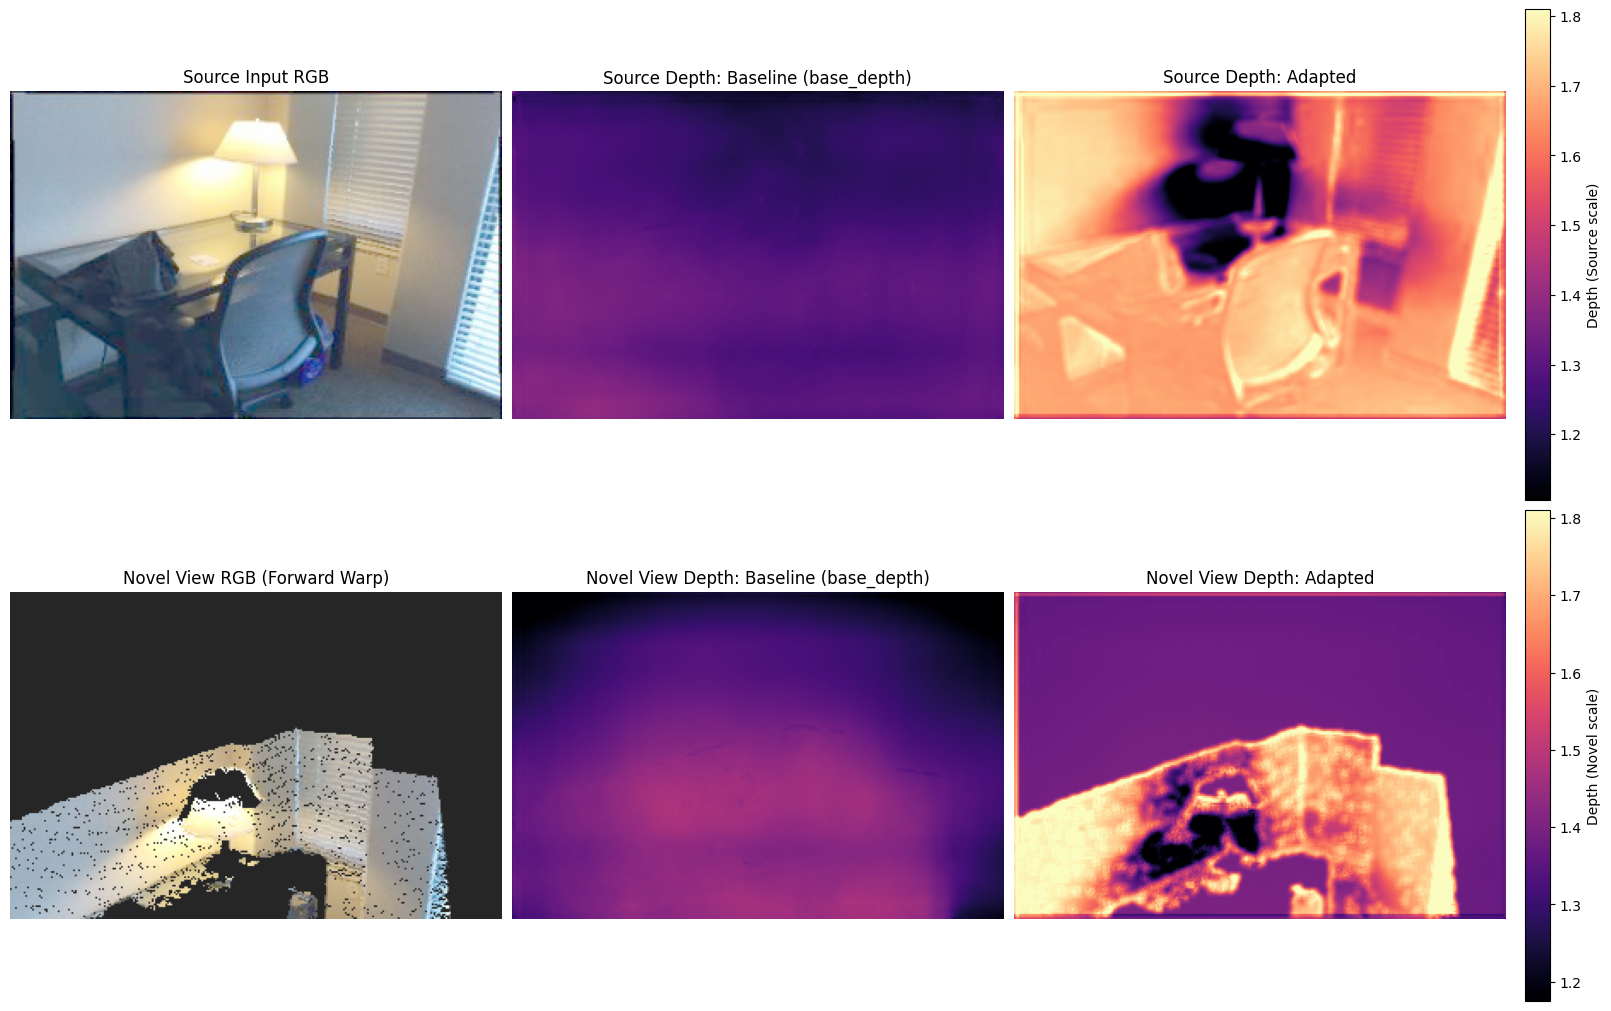

saved: /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/baseline_vs_adapted_input_novel_depth_panel.png


In [29]:
import numpy as np
import matplotlib.pyplot as plt

def rgb_for_display(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, 0.0, 1.0)
    lo, hi = np.percentile(x, [1, 99])
    x = np.clip((x - lo) / (hi - lo + 1e-6), 0.0, 1.0)
    return x ** (1 / 2.2)

def _depth_valid(a: np.ndarray) -> np.ndarray:
    return np.isfinite(a) & (a > 0)

def _depth_range(a: np.ndarray, b: np.ndarray):
    va = a[_depth_valid(a)]
    vb = b[_depth_valid(b)]
    joint = np.concatenate([va, vb]) if (va.size + vb.size) > 0 else np.array([], dtype=np.float32)
    if joint.size == 0:
        return 0.0, 1.0
    return np.percentile(joint, 2), np.percentile(joint, 98)

# Prefer "new visualization" semantics if packs are in scope:
# - baseline uses backbone base_depth
# - adapted uses adapted_depth
if "baseline_source_pack" in globals():
    src_base = baseline_source_pack["base_depth"][0].detach().cpu().numpy()
    nov_base = baseline_novel_pack["base_depth"][0].detach().cpu().numpy()
else:
    src_base = source_depth_baseline
    nov_base = novel_depth_baseline

if "adapted_source_pack" in globals():
    src_adapt = adapted_source_pack["adapted_depth"][0].detach().cpu().numpy()
    nov_adapt = adapted_novel_pack["adapted_depth"][0].detach().cpu().numpy()
else:
    src_adapt = source_depth_adapted
    nov_adapt = novel_depth_adapted

src_vmin, src_vmax = _depth_range(src_base, src_adapt)
nov_vmin, nov_vmax = _depth_range(nov_base, nov_adapt)

source_rgb_vis = rgb_for_display(source_rgb_np)
novel_rgb_vis = rgb_for_display(novel_rgb_np)

# make pure warp holes easier to read
holes = np.all(novel_rgb_np <= 1e-6, axis=-1)
novel_rgb_vis = novel_rgb_vis.copy()
novel_rgb_vis[holes] = np.array([0.15, 0.15, 0.15], dtype=np.float32)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

axes[0, 0].imshow(source_rgb_vis)
axes[0, 0].set_title("Source Input RGB")
axes[0, 0].axis("off")

im_src = axes[0, 1].imshow(src_base, cmap="magma", vmin=src_vmin, vmax=src_vmax)
axes[0, 1].set_title("Source Depth: Baseline (base_depth)")
axes[0, 1].axis("off")

axes[0, 2].imshow(src_adapt, cmap="magma", vmin=src_vmin, vmax=src_vmax)
axes[0, 2].set_title("Source Depth: Adapted")
axes[0, 2].axis("off")

axes[1, 0].imshow(novel_rgb_vis)
axes[1, 0].set_title("Novel View RGB (Forward Warp)")
axes[1, 0].axis("off")

im_nov = axes[1, 1].imshow(nov_base, cmap="magma", vmin=nov_vmin, vmax=nov_vmax)
axes[1, 1].set_title("Novel View Depth: Baseline (base_depth)")
axes[1, 1].axis("off")

axes[1, 2].imshow(nov_adapt, cmap="magma", vmin=nov_vmin, vmax=nov_vmax)
axes[1, 2].set_title("Novel View Depth: Adapted")
axes[1, 2].axis("off")

fig.colorbar(im_src, ax=[axes[0, 1], axes[0, 2]], fraction=0.025, pad=0.02, label="Depth (Source scale)")
fig.colorbar(im_nov, ax=[axes[1, 1], axes[1, 2]], fraction=0.025, pad=0.02, label="Depth (Novel scale)")

depth_compare_panel = TRAIN_RUN_OUTPUT_DIR / "baseline_vs_adapted_input_novel_depth_panel.png"
fig.savefig(depth_compare_panel, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", depth_compare_panel)


In [30]:
for name, d in [
    ("src_base", src_base), ("src_adapt", src_adapt),
    ("nov_base", nov_base), ("nov_adapt", nov_adapt),
]:
    v = d[np.isfinite(d) & (d > 0)]
    print(name, "min", float(v.min()), "max", float(v.max()), "std", float(v.std()))


src_base min 1.1360163688659668 max 1.4420318603515625 std 0.047110896557569504
src_adapt min 0.893796443939209 max 2.0056324005126953 std 0.18867379426956177
nov_base min 1.054896593093872 max 1.4850789308547974 std 0.0824413150548935
nov_adapt min 0.9764795899391174 max 2.0499982833862305 std 0.168489471077919


## Optional Inference Artifact

This produces one depth-preview artifact from the normalized dataset.


In [31]:
first_scene = TARGET_DATA_ROOT / scene_ids[0]
sample_image = next((first_scene / 'color').glob('*.jpg'))
infer_output = TRAIN_RUN_OUTPUT_DIR / 'sample_infer_depth.png'

infer_run = run(
    [
        'python', '-m', 'eaglevision.cli.infer_depth',
        '--input', str(sample_image),
        '--output', str(infer_output),
        '--mode', 'metric',
        '--encoder', 'vits',
        '--profile', 'hypersim',
    ],
    cwd=REPO_DIR,
    capture=True,
    check=False,
)

print('infer return code:', infer_run.returncode)
infer_output


$ python -m eaglevision.cli.infer_depth --input /kaggle/working/EagleVision/data/scannet/scene0000_00/color/1700.jpg --output /kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/sample_infer_depth.png --mode metric --encoder vits --profile hypersim
[status] cwd=/kaggle/working/EagleVision
[status] command started
[status] command finished with exit code 0
infer return code: 0


PosixPath('/kaggle/working/EagleVision/outputs/phase1_kaggle_heavy_v1/sample_infer_depth.png')

## Produced Artifacts

List the main artifacts generated by this run.


In [32]:
artifact_paths = sorted(str(path.relative_to(REPO_DIR)) for path in TRAIN_RUN_OUTPUT_DIR.rglob('*'))
artifact_paths[:200]


['outputs/phase1_kaggle_heavy_v1/adapted_metrics.yaml',
 'outputs/phase1_kaggle_heavy_v1/baseline_metrics.yaml',
 'outputs/phase1_kaggle_heavy_v1/baseline_vs_adapted_input_novel_depth_panel.png',
 'outputs/phase1_kaggle_heavy_v1/checkpoints',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_001_final_step_0003454.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_002_final_step_0006908.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_003_final_step_0010362.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_004_final_step_0013816.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_005_final_step_0017270.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_006_final_step_0020724.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_007_final_step_0024178.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_008_final_step_0027632.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/epoch_009_final_step_0031086.pt',
 'outputs/phase1_kaggle_heavy_v1/checkpoints/e

## Package Outputs For Export

This creates a zip file containing the run artifacts, metric summaries, and checkpoint outputs for later reuse.


In [33]:
archive_base = REPO_DIR / 'outputs' / 'phase1_kaggle_complete_export'
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=TRAIN_RUN_OUTPUT_DIR)
archive_path


'/kaggle/working/EagleVision/outputs/phase1_kaggle_complete_export.zip'

## Final Summary

This notebook demonstrates the full proposed Phase 1 workflow:

- baseline depth evaluation
- geometry-first adaptation training
- adapted evaluation
- direct baseline vs adapted comparison

If the adapted model improves the geometry-facing metrics while maintaining acceptable depth quality, that supports the central project hypothesis.
